# Amazon Sales — Exploratory Data Analysis

**Author:** *Your Name* &nbsp;|&nbsp; **Date:** August 2026

## Business Context

The dataset contains 3,203 individual order line items from a US-based retailer (Amazon/Walmart
marketplace sales) spanning **January 2011 – December 2014**. The goal of this notebook is to
understand the shape of the data, surface data quality issues, and answer a set of concrete
business questions before any modeling or dashboarding work begins.

## Business Questions

1. What does the distribution of Sales, Profit, and Quantity look like, and are there outliers?
2. Which regions and product categories drive the most revenue — and the most *profit*?
3. Is there a seasonal pattern in sales over time?
4. How do Sales, Quantity, Profit, and shipping speed relate to one another?
5. How reliable is on-time shipping, and does it affect profitability?
6. What data quality issues or anomalies need to be flagged before this data is trusted downstream?

## Dataset

| Field | Description |
|---|---|
| `Order ID`, `Order Date`, `Ship Date` | Order identifiers and key dates |
| `Status` | On time / Delay |
| `Customer Name`, `Country`, `City`, `Region` | Customer & geography |
| `Category`, `Product Name` | Product hierarchy |
| `Sales`, `Quantity`, `Profit` | Core numeric metrics |

---


## 1. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style="whitegrid", rc={"figure.dpi": 110})
plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "axes.titleweight": "bold",
    "axes.titlesize": 13,
})
PALETTE = ["#2E5EAA", "#DA6A4A", "#3FA796", "#E4B363", "#8E6C88", "#5B8C5A", "#C2455E"]

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")


In [2]:
df = pd.read_excel("../data/Amazon_sales.xlsx")
print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
df.head()


Shape: 3,203 rows x 13 columns


,Order ID,Order Date,Ship Date,Status,Customer Name,Country,City,Region,Category,Product Name,Sales,Quantity,Profit
0,CA-2013-138688,2013-06-13,2013-06-17,On time,DarrinVanHuff,United States,Los Angeles,California,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62,2,6.87
1,CA-2011-115812,2011-06-09,2011-06-14,Delay,BrosinaHoffman,United States,Los Angeles,California,Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.86,7,14.17
2,CA-2011-115812,2011-06-09,2011-06-14,Delay,BrosinaHoffman,United States,Los Angeles,California,Art,Newell 322,7.28,4,1.97
3,CA-2011-115812,2011-06-09,2011-06-14,Delay,BrosinaHoffman,United States,Los Angeles,California,Phones,Mitel 5320 IP Phone VoIP phone,907.15,4,90.72
4,CA-2011-115812,2011-06-09,2011-06-14,Delay,BrosinaHoffman,United States,Los Angeles,California,Binders,DXL Angle-View Binders with Locking Rings by S...,18.50,3,5.78


## 2. Data Quality Check

Before drawing any conclusions, confirm the data is clean: check dtypes, missing values,
duplicate rows, and the sensibility of date ranges.

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3203 entries, 0 to 3202
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Order ID       3203 non-null   str           
 1   Order Date     3203 non-null   datetime64[us]
 2   Ship Date      3203 non-null   datetime64[us]
 3   Status         3203 non-null   str           
 4   Customer Name  3203 non-null   str           
 5   Country        3203 non-null   str           
 6   City           3203 non-null   str           
 7   Region         3203 non-null   str           
 8   Category       3203 non-null   str           
 9   Product Name   3203 non-null   str           
 10  Sales          3203 non-null   float64       
 11  Quantity       3203 non-null   int64         
 12  Profit         3203 non-null   float64       
dtypes: datetime64[us](2), float64(2), int64(1), str(8)
memory usage: 325.4 KB


In [4]:
missing = df.isnull().sum()
dupes = df.duplicated().sum()
print("Missing values per column:")
print(missing[missing > 0] if missing.sum() else "None — dataset has no missing values.")
print(f"\nExact duplicate rows: {dupes}")


Missing values per column:
None — dataset has no missing values.

Exact duplicate rows: 0


In [5]:
# Feature engineering: fields needed for the analysis below
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])
df["Ship Delay (days)"] = (df["Ship Date"] - df["Order Date"]).dt.days
df["Profit Margin"] = df["Profit"] / df["Sales"]
df["Order Month"] = df["Order Date"].dt.to_period("M").dt.to_timestamp()

print(f"Date range: {df['Order Date'].min().date()} -> {df['Order Date'].max().date()}")
print(f"Any Ship Date before Order Date? {(df['Ship Delay (days)'] < 0).any()}")


Date range: 2011-01-07 -> 2014-12-31
Any Ship Date before Order Date? False


**Data quality summary:** no missing values, no duplicate rows, and every shipment date
falls on or after its order date. The dataset is clean enough to analyze directly, with no
imputation or row-dropping required.

## 3. Descriptive Statistics

In [6]:
numeric_cols = ["Sales", "Quantity", "Profit", "Ship Delay (days)"]
df[numeric_cols].describe().T


,count,mean,std,min,25%,50%,75%,max
Sales,"3,203.00",226.49,524.88,0.99,19.44,60.84,215.81,"13,999.96"
Quantity,"3,203.00",3.83,2.26,1.00,2.00,3.00,5.00,14.00
Profit,"3,203.00",33.85,174.11,"-3,399.98",3.85,11.17,33.00,"6,719.98"
Ship Delay (days),"3,203.00",3.93,1.81,0.00,3.00,4.00,5.00,7.00


**Observations:**
- Sales and Profit are both heavily **right-skewed** — the mean Sale ($226) is nearly 4x the
  median ($61), and the standard deviation for Sales ($525) *exceeds* the mean, a classic signature
  of a long tail of high-value outliers rather than a normal distribution.
- **318 orders (9.9%) were sold at a loss** — negative Profit — despite a healthy overall margin
  (computed below).
- Ship Delay ranges 0–7 days with a median of 4 days.

In [7]:
neg_profit_orders = (df["Profit"] < 0).sum()
neg_profit_pct = (df["Profit"] < 0).mean() * 100
overall_margin = df["Profit"].sum() / df["Sales"].sum() * 100

print(f"Orders sold at a loss: {neg_profit_orders} ({neg_profit_pct:.1f}%)")
print(f"Total Sales:  ${df['Sales'].sum():,.2f}")
print(f"Total Profit: ${df['Profit'].sum():,.2f}")
print(f"Overall Profit Margin: {overall_margin:.1f}%")


Orders sold at a loss: 318 (9.9%)
Total Sales:  $725,457.82
Total Profit: $108,418.45
Overall Profit Margin: 14.9%


## 4. Univariate Analysis — Distributions

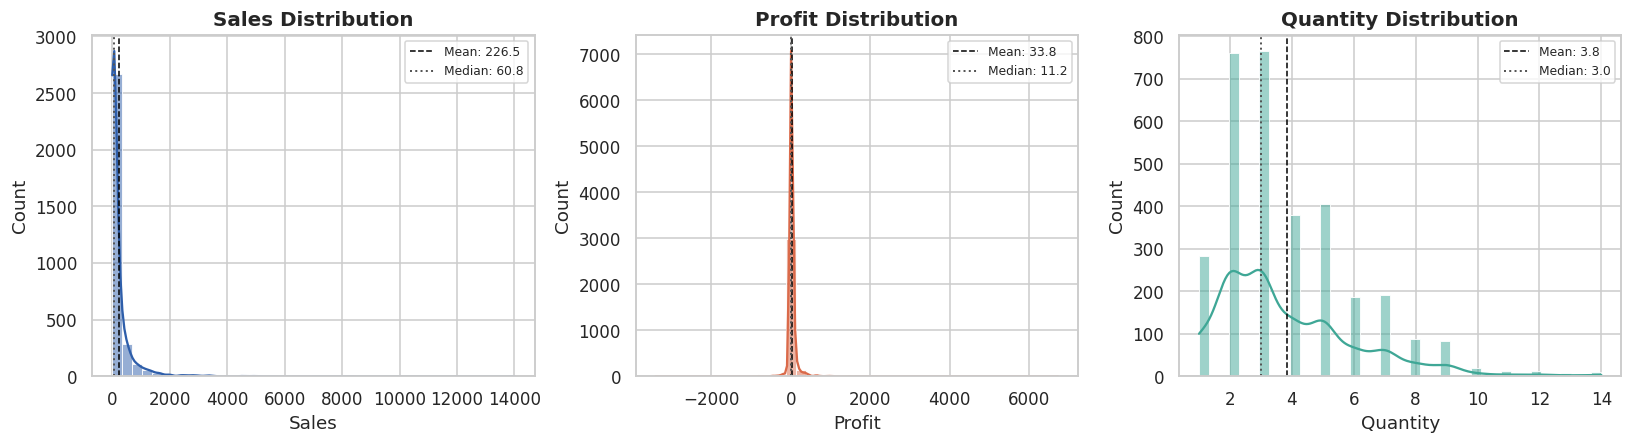

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
for ax, col, color in zip(axes, ["Sales", "Profit", "Quantity"], PALETTE[:3]):
    data = df[col]
    sns.histplot(data, bins=40, ax=ax, color=color, kde=True, edgecolor="white")
    ax.axvline(data.mean(), color="black", linestyle="--", linewidth=1, label=f"Mean: {data.mean():,.1f}")
    ax.axvline(data.median(), color="#555555", linestyle=":", linewidth=1.3, label=f"Median: {data.median():,.1f}")
    ax.set_title(f"{col} Distribution")
    ax.legend(fontsize=8)
fig.tight_layout()
plt.savefig("../images/01_distributions.png", bbox_inches="tight")
plt.show()


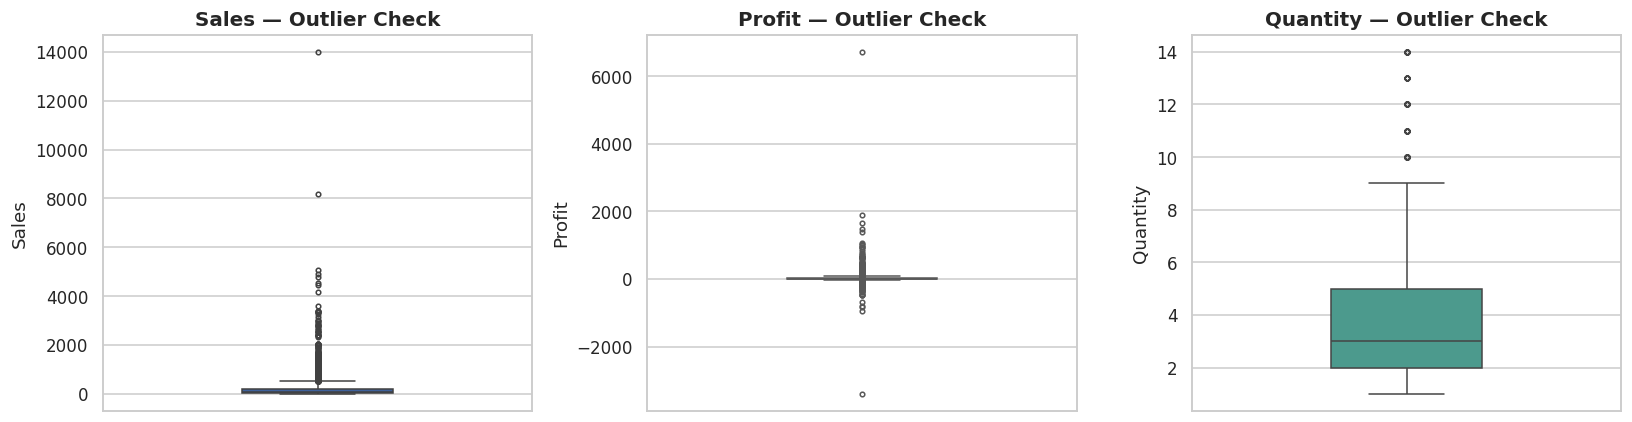

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col, color in zip(axes, ["Sales", "Profit", "Quantity"], PALETTE[:3]):
    sns.boxplot(y=df[col], ax=ax, color=color, width=0.35, fliersize=3)
    ax.set_title(f"{col} — Outlier Check")
fig.tight_layout()
plt.savefig("../images/02_boxplots.png", bbox_inches="tight")
plt.show()


**Takeaway:** Sales and Profit both show many points beyond the boxplot whiskers — Sales
skews entirely high, while Profit has outliers on *both* sides (some orders lose over $3,000,
others earn nearly $6,720). Quantity is comparatively well-behaved, mostly 1–14 units.

## 5. Where the Revenue Comes From — Region & Category

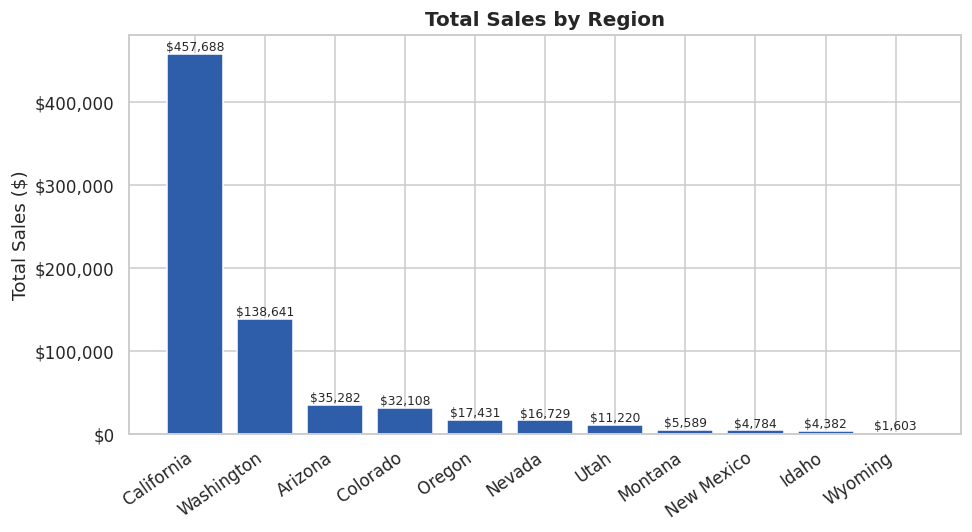

,Total Sales,Pct_of_Total
Region,,
California,"457,687.63",63.10
Washington,"138,641.27",19.10
Arizona,"35,282.00",4.90
Colorado,"32,108.12",4.40
Oregon,"17,431.15",2.40
Nevada,"16,729.10",2.30
Utah,"11,220.06",1.50
Montana,"5,589.35",0.80
New Mexico,"4,783.52",0.70


In [10]:
region_sales = df.groupby("Region")["Sales"].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(region_sales.index, region_sales.values, color=PALETTE[0])
ax.set_title("Total Sales by Region")
ax.set_ylabel("Total Sales ($)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f"${x:,.0f}"))
plt.setp(ax.get_xticklabels(), rotation=35, ha="right")
for b in bars:
    ax.annotate(f"${b.get_height():,.0f}", (b.get_x() + b.get_width() / 2, b.get_height()),
                ha="center", va="bottom", fontsize=8)
fig.tight_layout()
plt.savefig("../images/03_sales_by_region.png", bbox_inches="tight")
plt.show()

region_sales.to_frame("Total Sales").assign(
    Pct_of_Total=lambda d: (d["Total Sales"] / d["Total Sales"].sum() * 100).round(1)
)


**California dominates**, generating **$457,688** — 63% of all sales — more than 3x every
other region combined. This is a real geographic concentration risk for the business.

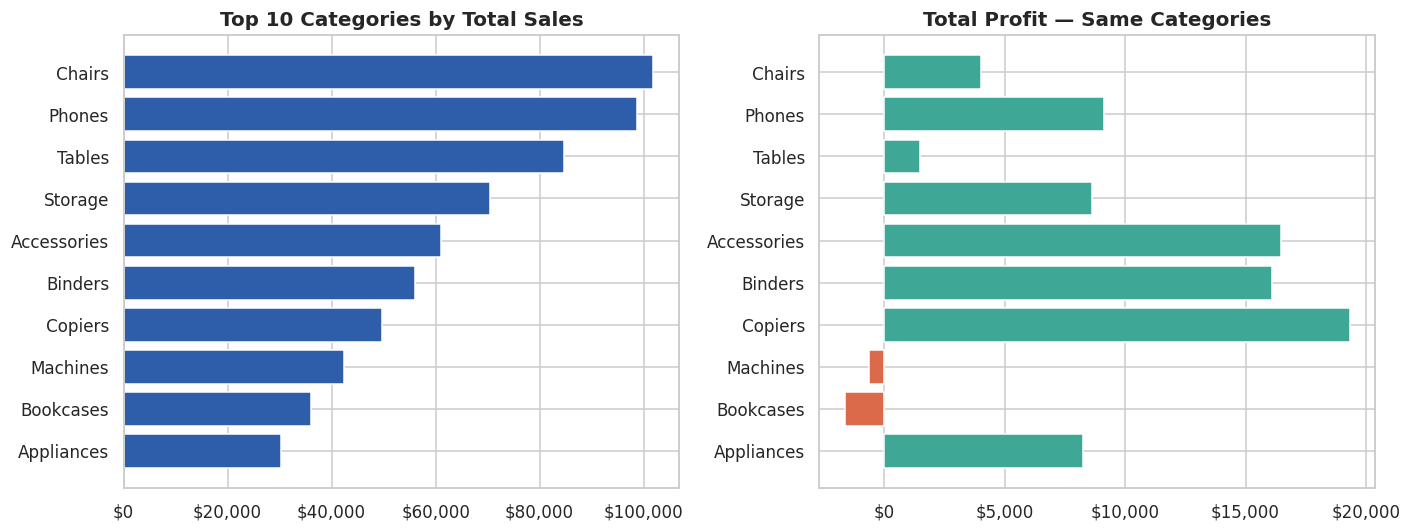

,Sales,Profit
Category,,
Chairs,"101,781.33","4,027.58"
Phones,"98,684.35","9,110.74"
Tables,"84,754.56","1,482.61"
Storage,"70,532.85","8,645.32"
Accessories,"61,114.12","16,484.60"
Binders,"55,961.11","16,096.80"
Copiers,"49,749.24","19,327.24"
Machines,"42,444.12",-618.93
Bookcases,"36,004.12","-1,646.51"


In [11]:
cat_stats = (
    df.groupby("Category")
    .agg(Sales=("Sales", "sum"), Profit=("Profit", "sum"))
    .sort_values("Sales", ascending=False)
    .head(10)
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].barh(cat_stats.index[::-1], cat_stats["Sales"][::-1], color=PALETTE[0])
axes[0].set_title("Top 10 Categories by Total Sales")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f"${x:,.0f}"))

colors_profit = [PALETTE[2] if v >= 0 else PALETTE[1] for v in cat_stats["Profit"][::-1]]
axes[1].barh(cat_stats.index[::-1], cat_stats["Profit"][::-1], color=colors_profit)
axes[1].set_title("Total Profit — Same Categories")
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f"${x:,.0f}"))

fig.tight_layout()
plt.savefig("../images/04_top_categories.png", bbox_inches="tight")
plt.show()

cat_stats


**Sales rank and profit rank don't match.** Chairs and Phones lead in raw sales, but
**Copiers** generate the highest profit ($19,327) on comparatively modest sales. Two categories
are net **unprofitable overall**: **Machines** (-$619) and **Bookcases** (-$1,647), despite
meaningful sales volume ($42K and $36K respectively) — candidates for a pricing or cost review.

## 6. Sales Trend Over Time

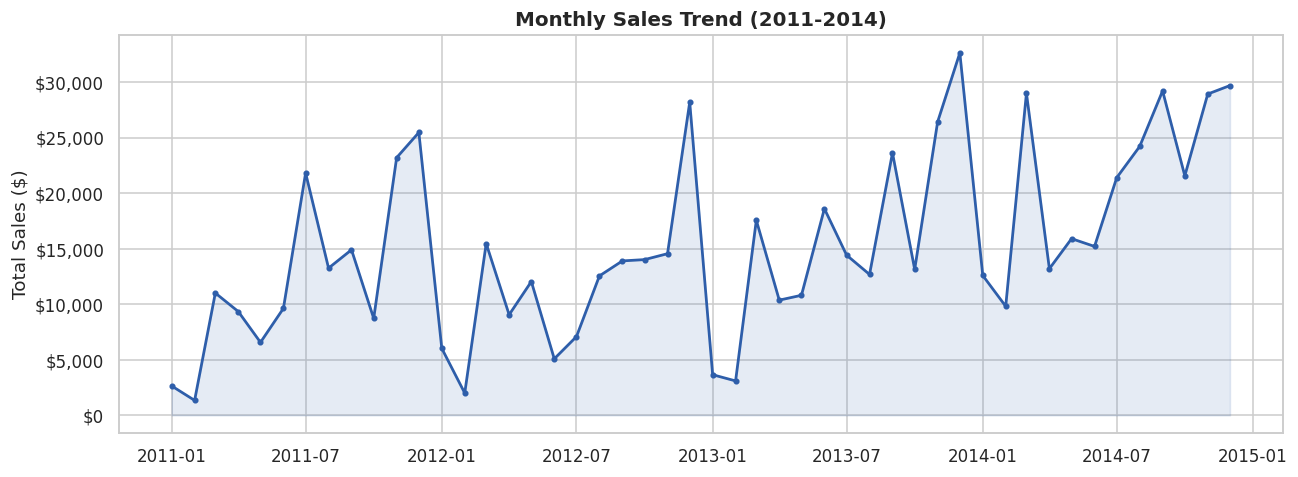

In [12]:
monthly = df.groupby("Order Month")["Sales"].sum()

fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(monthly.index, monthly.values, color=PALETTE[0], linewidth=1.8, marker="o", markersize=3)
ax.fill_between(monthly.index, monthly.values, color=PALETTE[0], alpha=0.12)
ax.set_title("Monthly Sales Trend (2011-2014)")
ax.set_ylabel("Total Sales ($)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f"${x:,.0f}"))
fig.tight_layout()
plt.savefig("../images/05_monthly_trend.png", bbox_inches="tight")
plt.show()


Sales show a clear **seasonal spike every November/December**, consistent with holiday
shopping, plus a general upward trajectory — later years have higher highs *and* higher lows,
which points to underlying growth rather than pure volatility.

## 7. Bivariate Analysis — Relationships Between Variables

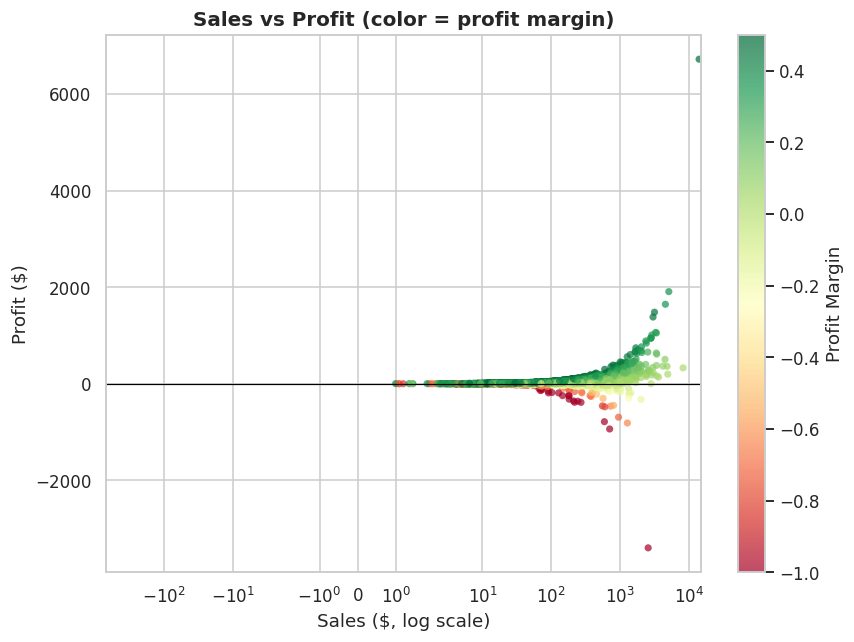

In [13]:
fig, ax = plt.subplots(figsize=(8, 6))
colors = df["Profit Margin"].clip(-1, 1)
sc = ax.scatter(df["Sales"], df["Profit"], c=colors, cmap="RdYlGn", s=22, alpha=0.7, edgecolor="none")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xscale("symlog")
ax.set_title("Sales vs Profit (color = profit margin)")
ax.set_xlabel("Sales ($, log scale)")
ax.set_ylabel("Profit ($)")
cbar = fig.colorbar(sc, ax=ax)
cbar.set_label("Profit Margin")
fig.tight_layout()
plt.savefig("../images/06_sales_vs_profit.png", bbox_inches="tight")
plt.show()


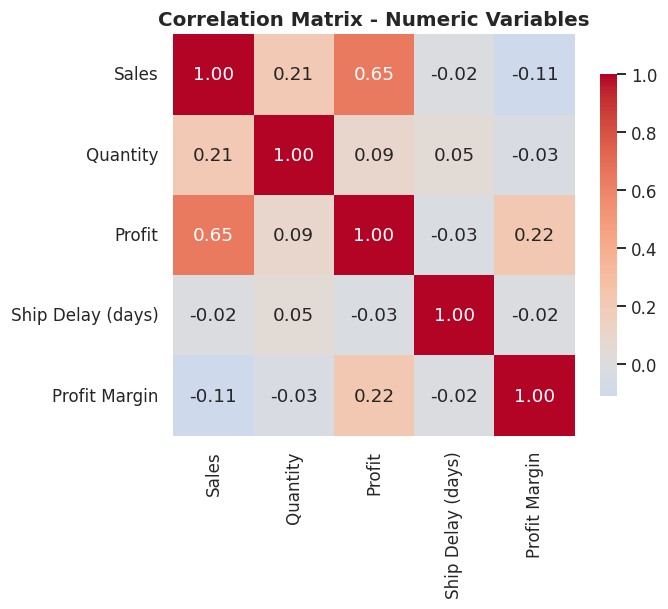

,Sales,Quantity,Profit,Ship Delay (days),Profit Margin
Sales,1.00,0.21,0.65,-0.02,-0.11
Quantity,0.21,1.00,0.09,0.05,-0.03
Profit,0.65,0.09,1.00,-0.03,0.22
Ship Delay (days),-0.02,0.05,-0.03,1.00,-0.02
Profit Margin,-0.11,-0.03,0.22,-0.02,1.00


In [14]:
num_cols = ["Sales", "Quantity", "Profit", "Ship Delay (days)", "Profit Margin"]
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(6.5, 5.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax,
            square=True, cbar_kws={"shrink": 0.8})
ax.set_title("Correlation Matrix - Numeric Variables")
fig.tight_layout()
plt.savefig("../images/07_correlation_heatmap.png", bbox_inches="tight")
plt.show()

corr


| Relationship | Correlation | Interpretation |
|---|---:|---|
| Sales vs Profit | 0.65 | Moderate-strong positive — bigger orders usually mean more profit |
| Quantity vs Sales | 0.21 | Weak — buying more units doesn't scale sales proportionally |
| Ship Delay vs Profit | -0.03 | Essentially no relationship |

Low-value orders show the **widest margin spread** (from deeply negative to strongly positive),
while high-value orders are almost uniformly profitable — with one striking exception: a single
~$2,500 order that lost nearly $3,400, the dataset's clearest anomaly (flagged in Section 9).

## 8. Shipping Performance

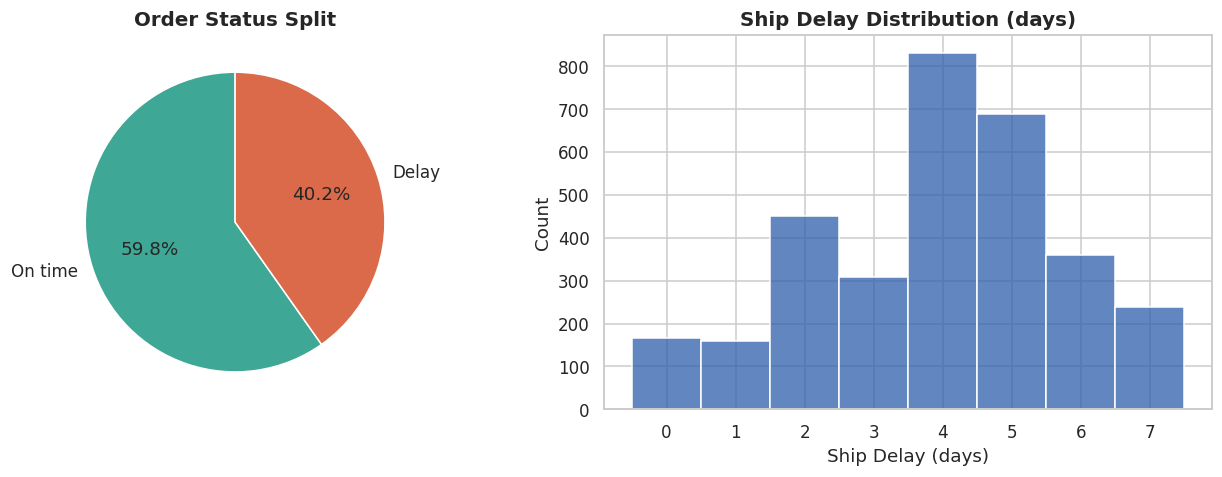

Correlation between Ship Delay and Profit: -0.029


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

status_counts = df["Status"].value_counts()
axes[0].pie(status_counts.values, labels=status_counts.index, autopct="%1.1f%%",
            colors=[PALETTE[2], PALETTE[1]], startangle=90, wedgeprops={"edgecolor": "white"})
axes[0].set_title("Order Status Split")

sns.histplot(df["Ship Delay (days)"], bins=8, color=PALETTE[0], ax=axes[1], discrete=True, edgecolor="white")
axes[1].set_title("Ship Delay Distribution (days)")

fig.tight_layout()
plt.savefig("../images/08_shipping.png", bbox_inches="tight")
plt.show()

print(f"Correlation between Ship Delay and Profit: {df['Ship Delay (days)'].corr(df['Profit']):.3f}")


**40% of orders (1,288 of 3,203) shipped with a delay.** Delay days are spread fairly evenly
from 0–7 with no dominant window, which looks like a broad operational issue rather than one
isolated cause. Delay does **not** correlate with lower profit, so this is a customer-experience
metric to fix on its own merits — not a lever for margin improvement.

## 9. Anomaly Flag — Manual Audit Candidate

In [16]:
outlier = df.loc[df["Profit"].idxmin()]
outlier[["Order ID", "Order Date", "Category", "Product Name", "Sales", "Quantity", "Profit", "Profit Margin"]]


Order ID                                    CA-2014-134845
Order Date                             2014-04-18 00:00:00
Category                                          Machines
Product Name     Lexmark MX611dhe Monochrome Laser Printer
Sales                                             2,549.99
Quantity                                                 5
Profit                                           -3,399.98
Profit Margin                                        -1.33
Name: 969, dtype: object

This single line item lost **~$3,400 on a ~$2,500 sale** — a profit margin worse than -100%,
meaning the cost recorded exceeds not just the sale price but the entire recorded margin logic for
similar orders. This is the most likely candidate in the dataset for a data-entry error, an
unusually steep discount, or a return/refund miscoded as a regular sale, and should be verified
against source records before this data feeds any pricing or forecasting model.

## 10. Key Findings & Recommendations

| # | Finding | Recommendation |
|---|---|---|
| 1 | California alone drives 63% of sales | Investigate geographic expansion opportunities to reduce concentration risk |
| 2 | Sales rank != profit rank (Tables, Machines barely profitable; Copiers highly profitable) | Review pricing/cost structure for Tables, Machines, and Bookcases |
| 3 | ~10% of orders lose money, concentrated in low/mid-price items | Set a minimum-margin threshold or review discounting rules for low-ticket items |
| 4 | Clear Nov/Dec seasonal spike | Align inventory and staffing planning with the holiday peak |
| 5 | 40% of shipments are delayed, with no profit impact | Treat as a service-quality initiative, separate from margin work |
| 6 | One extreme -$3,400 profit outlier | Manually audit this order before including it in any downstream model |

---
*Analysis performed with `pandas`, `matplotlib`, and `seaborn`. See `../README.md` for project
setup and how to reproduce this notebook.*
